<H1>Capstone Project 1</H1>

<H3>What behavioural differences between casual riders and annual members can guide targeted marketing strategies to convert casual riders into annual members and drive revenue growth?</H3>

<H4>Key stakeholder(s): The director of Marketing and the executive team.</H4>

<H5>Contents of the notebook</H5>
<ol>
<li>Introduction</li>
<li>Data Preparation</li>
<li>Data Processing</li>
<li>Data Analysis</li>
<li>Data Visualization</li>
<li>Insights from Analysis</li>
<li>Key Recommendations</li>
</ol>

<H4>Introduction

This project analyzes data from Cyclistic, a bike-share company based in Chicago. As a junior data analyst on the marketing analytics team, the goal is to support the marketing department in making data-driven decisions.
The director of marketing believes that the company’s long-term growth depends on increasing the number of annual memberships. Currently, Cyclistic has two main types of customers: casual riders, who purchase single-ride or day passes, and annual members, who subscribe to yearly memberships.

To support the company’s strategy, this project focuses on understanding how casual riders and annual members use Cyclistic bikes differently. By analyzing historical trip data, patterns in rider behavior will be identified, such as ride duration, frequency, and time of usage.
The insights generated from this analysis will help the marketing team design targeted strategies aimed at converting casual riders into annual members, ultimately supporting the company’s growth and customer retention goals.

<H4>Data Preparation</H5>

The dataset used for this analysis consists of Cyclistic historical trip data (year 2025) made publicly available by Divvy. The data includes trip-level information such as ride ID, rideable type, start and end timestamps, station names, and rider classification (casual or annual member).
The data was downloaded in CSV format and stored locally. It covers a full year of trip activity, allowing seasonal and behavioural pattern comparison.
The dataset is reliable and original, as it originates from Cyclistic’s operational systems. It does not contain personally identifiable information, ensuring compliance with privacy standards.
While comprehensive in trip-level details, the dataset lacks demographic and revenue-specific data, limiting deeper customer segmentation analysis.


1. Combining the csv files into a single dataframe, 'trip_data'

In [10]:
import pandas as pd

In [11]:
jan = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Jan2025 trip data.csv")
feb = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Feb2025 trip data.csv")
mar = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Mar2025 trip data.csv")
apr = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Apr2025 trip data.csv")
may = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\May2025 trip data.csv")
jun = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Jun2025 trip data.csv")
jul = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Jul2025 trip data.csv")
aug = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Aug2025 trip data.csv")
sep = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Sep2025 trip data.csv")
octo = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Oct2025 trip data.csv")
nov = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Nov2025 trip data.csv")
dec = pd.read_csv(r"D:\DEBOSMITA BASAK\Capstone project_coursera\Case study 1\Datasets\Dec2025 trip data.csv")

In [12]:
trip_data = pd.concat([jan, feb, mar, apr, may, jun, jul, aug, sep, octo, nov, dec], ignore_index = True)

2. Description of the Dataframe

In [14]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552994 entries, 0 to 5552993
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 550.8+ MB


The pre-processed dataframe 'trip_data' has 5552994 rows and 13 columns.

<H4>Data Processing</H5>

The datasets used in this project consists of millions of rows, making it impractical to process using spreadsheet applications. To overcome this limitation, Python was used, as it provides powerful libraries for handling and analyzing large datasets efficiently.

1. Convert 'started_at' and 'ended_at' columns to datetime datatype.

In [19]:
trip_data['started_at'] = pd.to_datetime(trip_data['started_at'])
trip_data['ended_at'] = pd.to_datetime(trip_data['ended_at'])

2. Adding a new column 'ride_duration' to the dataframe.

In [21]:
trip_data['ride_duration'] = (trip_data['ended_at'] - trip_data['started_at']).dt.total_seconds()/60

3. Adding a new column 'day_of week' to the dataframe.

In [23]:
trip_data['day_of_week'] = trip_data['started_at'].dt.day_name()

4. Cleaning the dataset to keep those rides whose ride duration > 0

In [25]:
trip_data = trip_data[trip_data['ride_duration']> 0]

5. Check for missing values in the dataset


In [27]:
trip_data.isna().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1184669
start_station_id      1184669
end_station_name      1243299
end_station_id        1243299
start_lat                   0
start_lng                   0
end_lat                  5535
end_lng                  5535
member_casual               0
ride_duration               0
day_of_week                 0
dtype: int64

6. Check for duplicate entries in the ride_id column


In [29]:
trip_data['ride_id'].duplicated().sum()

0

7. Percentage of rows with missing 'start_station_name' and 'end_station_name'


In [31]:
trip_data[['start_station_name','end_station_name']].isna().mean()*100

start_station_name    21.333990
end_station_name      22.389822
dtype: float64

About 22% rows have missing station details. Removing those rows of data will be disadvantageous.

8. Filling in the missing station names with 'Unknown'. This prevents losing a considerable amount of data.

In [34]:
trip_data.loc[:,'start_station_name'] = trip_data['start_station_name'].fillna('Unknown')
trip_data.loc[:,'end_station_name'] = trip_data['end_station_name'].fillna('Unknown')

<H5>Rows with missing station names were retained and labeled as 'Unknown' to avoid losing a large portion of the dataset.

9. Adding a new column 'month' to the dataset.

In [37]:
trip_data = trip_data.copy()
trip_data['month'] = trip_data['started_at'].dt.month_name()

<H5>Preview of the dataset after data preparation and processing</H5>

In [39]:
trip_data.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration,day_of_week,month
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member,13.957950,Tuesday,January
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member,5.072400,Saturday,January
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member,11.591667,Thursday,January
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,3.570550,Thursday,January
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,2.573817,Thursday,January


<H5>Description of the dataframe after data processing</H5>

In [41]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5552965 entries, 0 to 5552993
Data columns (total 16 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
 13  ride_duration       float64       
 14  day_of_week         object        
 15  month               object        
dtypes: datetime64[ns](2), float64(5), object(9)
memory usage: 720.2+ MB


The post-processed dataframe has 3 extra columns, as expected. The dimension is 5552994 rows and 16 columns. Please note the change in the datatype of 'started_at' and 'ended_at' columns.

<H4>Data Analysis</H5>

1. Total number of trips per user type

In [45]:
trip_data[['member_casual']].value_counts().reset_index()

,member_casual,count
0,member,3553477
1,casual,1999488


2. Average ride duration per user type

In [47]:
trip_data.groupby("member_casual")['ride_duration'].mean().reset_index()

,member_casual,ride_duration
0,casual,22.595925
1,member,12.332356


3. Number of rides per day per user type

In [49]:
trip_data.groupby(['day_of_week','member_casual']).size().reset_index(name = 'no.of_rides')

,day_of_week,member_casual,no.of_rides
0,Friday,casual,320077
1,Friday,member,528989
2,Monday,casual,228253
3,Monday,member,502767
4,Saturday,casual,414206
5,Saturday,member,450199
6,Sunday,casual,331783
7,Sunday,member,382293
8,Thursday,casual,258045
9,Thursday,member,576005


4. No. of rides per month per user type

In [51]:
trip_data.groupby(['month','member_casual']).size().reset_index(name = 'no.of_rides')

,month,member_casual,no.of_rides
0,April,casual,109239
1,April,member,262137
2,August,casual,337878
3,August,member,452439
4,December,casual,28112
5,December,member,112463
6,February,casual,27757
7,February,member,124144
8,January,casual,24124
9,January,member,114527


<H4>Data Visualization

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

1. Annual members vs Casual users Usage Volume

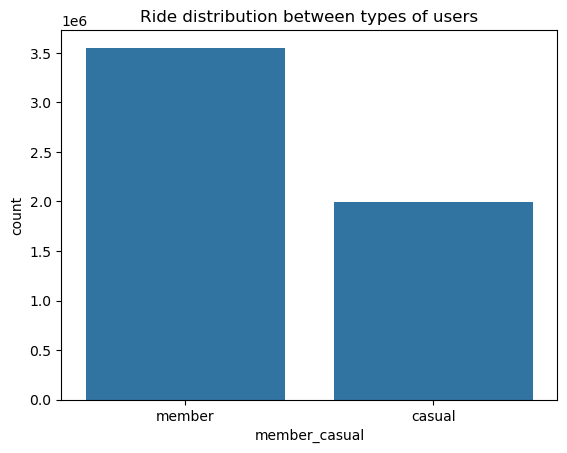

In [55]:
sns.countplot(data = trip_data, x = 'member_casual')
plt.title ("Ride distribution between types of users")
plt.show()

The total number of rides taken by Annual members is approximately 1.5 times higher than that of Casual users.

2. Ride distribution between users per day of week

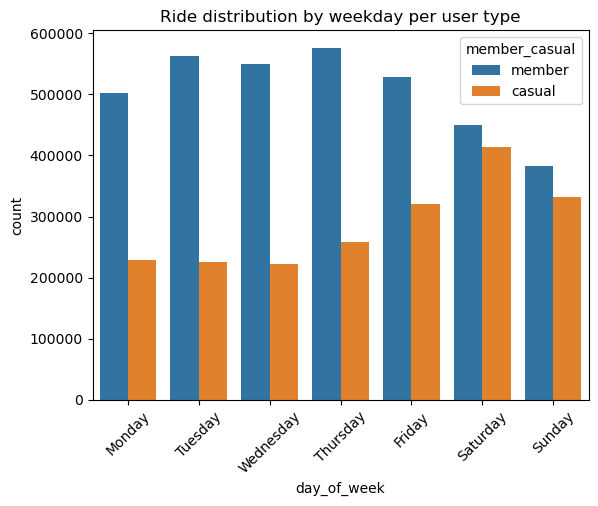

In [58]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=trip_data, x='day_of_week', hue='member_casual', order = day_order)
plt.title ("Ride distribution by weekday per user type")
plt.xticks(rotation = 45)
plt.show()

Casual Riders took the maximum number of rides on Saturday and Sunday.


3. Average ride duration between user types

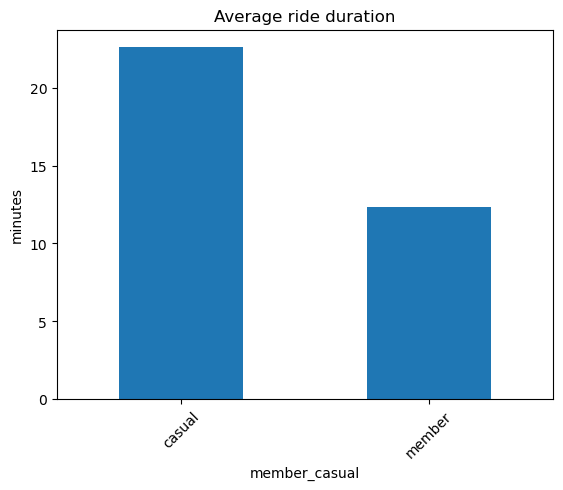

In [61]:
trip_data.groupby("member_casual")['ride_duration'].mean().plot(kind = 'bar')
plt.title("Average ride duration")
plt.xticks(rotation = 45)
plt.ylabel("minutes")
plt.show()

Casual riders tend to take longer rides as compared to Annual members.

4. Monthly ride trends

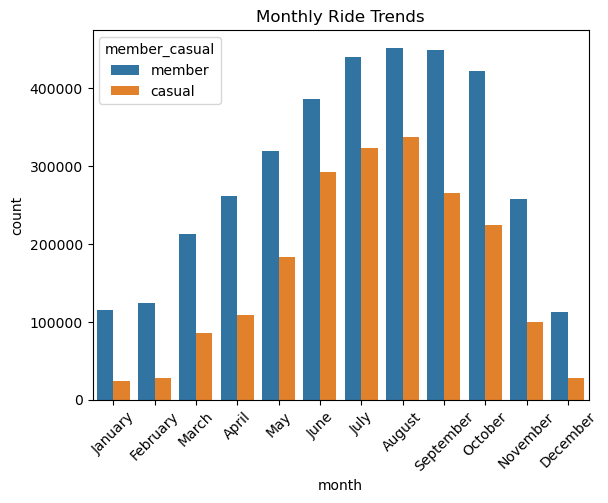

In [64]:
order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=trip_data, x='month', hue='member_casual', order = order)
plt.title("Monthly Ride Trends")
plt.xticks (rotation = 45)
plt.show()

For both types of users, the number of rides has increased gradually over the months, till August, post which the curve is declining.
Casual riders took most rides in the month of June-July-August.

5. Ride duration distribution

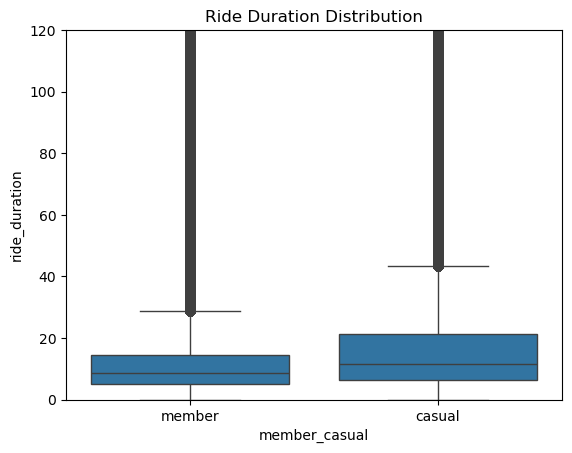

In [67]:
sns.boxplot(data=trip_data, x='member_casual', y='ride_duration')
plt.ylim(0,120)
plt.title("Ride Duration Distribution")
plt.show()

Median (center line in the box):- The median ride duration for casual riders is higher than for members. Casual riders take longer trips.

Box (middle 50% of rides; Interquartile-range):- The box for casual riders is taller, showing more variability in ride duration. Members have a smaller box, indicating more consistent ride times.

Whiskers (typical range of rides):- Casual riders have a larger upper range, meaning they sometimes take much longer rides. Members generally stay within shorter ride durations.

The boxplot shows that casual riders generally take longer and more variable trips compared to annual members. Members display shorter and more consistent ride durations, suggesting they primarily use bikes for routine commuting, while casual riders are more likely using the service for leisure activities.

6. Average Ride Duration by Day of Week

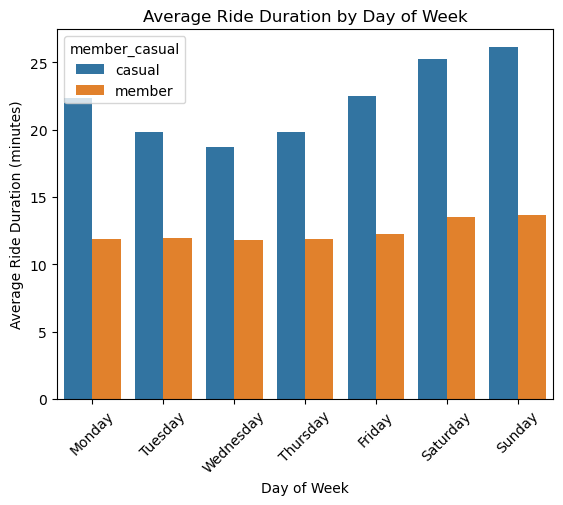

In [70]:
avg_duration = trip_data.groupby(['day_of_week','member_casual'])['ride_duration'].mean().reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=avg_duration, x='day_of_week', y='ride_duration', hue='member_casual', order = day_order)

plt.title("Average Ride Duration by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Ride Duration (minutes)")
plt.xticks(rotation=45)
plt.show()

The avg ride duration for casual riders is highest on Weekends.

<H4>Insights from Analysis</H4>

1. Annual members take significantly more rides than casual riders. Over the year, the total number of rides taken by members is approximately 1.5 times higher than that of casual riders, indicating that members rely on the service more regularly.
2. Casual riders show a clear weekend usage pattern, with the highest number of rides occurring on Saturday and Sunday. This suggests that casual riders primarily use the bikes for leisure or recreational purposes.
3. Casual riders generally take longer and more variable trips compared to annual members. In contrast, members display shorter and more consistent ride durations, suggesting that they primarily use bikes for routine commuting or daily transportation.
4. The average ride duration for casual riders peaks during weekends, further reinforcing the idea that casual riders use the service for leisure activities, while members use it more consistently throughout the week.
5. For both user types, the number of rides gradually increases throughout the year until August, after which ride activity begins to decline. This trend likely reflects seasonal factors such as weather conditions.
6. Casual rider activity is highest during the summer months (June, July, and August). This indicates that casual usage is strongly influenced by favorable weather and outdoor recreational opportunities.

<H4>Key Recommendations</H4>

1. Offer membership promotions on weekends

The analysis shows that casual riders take the most rides on Saturday and Sunday. Cyclistic could promote annual memberships during weekends, since casual riders are more active at that time. For example, the company could offer weekend discounts or free trial memberships to encourage casual riders to become members.

2. Run promotions during the summer months

Casual riders take the most rides during June, July, and August. Cyclistic could run marketing campaigns or special offers during these months to encourage casual riders to sign up for annual memberships.

3. Highlight the benefits of membership for frequent riders

Annual members take rides more regularly throughout the week. Cyclistic could promote the advantages of membership, such as lower cost per ride and convenience for daily commuting. This might encourage casual riders who ride often to switch to a membership plan.

<H4><li>Last Updated on: 8th March, 2026</li>
<li>Prepared by: Debosmita Basak</li></H4>